<h1 style="text-align: center;">Module 1. Structured data processing using neural networks
</h1>
<h2 style="text-align: center;">Topic 2. Logistic regression. Artificial neuron</h2>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Dict

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings
# filter warnings
warnings.filterwarnings('ignore')

## Dataset overview

[Spaceship Titanic dataset](https://www.kaggle.com/competitions/spaceship-titanic/overview)

**Data Field Description:**
* `PassengerId` - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
* `HomePlanet` - The planet the passenger departed from, typically their planet of permanent residence.
* `CryoSleep` - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* `Cabin` - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
* `Destination` - The planet the passenger will be debarking to.
* `Age` - The age of the passenger.
* `VIP` - Whether the passenger has paid for special VIP service during the voyage.
* `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
* `Name` - The first and last names of the passenger.
* `Transported` - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

## Exploratory Data Analysis

In [4]:
# Reading data

df = pd.read_csv('../data/Module_1_Lecture_2_Class_Spaceship_Titanic.csv')
df = df.set_index('PassengerId')

In [5]:
# Dataset preview

df.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
# Number of records and columns

df.shape

(8693, 13)

In [7]:
names, surnames = [], []
for name, surname in df.Name.dropna().apply(lambda x: x.split()):
    names.append(name)
    surnames.append(surname)

In [8]:
pd.Series(names).value_counts()

Idace     13
Loree     12
Dandra    11
Kaye      11
Gwendy    11
          ..
Carves     1
Per        1
Ants       1
Gian       1
Chain      1
Name: count, Length: 2706, dtype: int64

In [9]:
# Basic dataset info 

df.info()

<class 'pandas.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   str    
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   str    
 3   Destination   8511 non-null   str    
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   str    
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(4)
memory usage: 1.1+ MB


In [10]:
TARGET = 'Transported'
FEATURES = [col for col in df.columns if col != TARGET]

In [11]:
text_features = ["Cabin", "Name"]
cat_features = [col for col in FEATURES if df[col].nunique() < 25 and col not in text_features ]
cont_features = [col for col in FEATURES if df[col].nunique() >= 25 and col not in text_features ]

In [12]:
print(f'Number of categorical features: {len(cat_features)}')
print('Categorical features:', cat_features, '\n')
print(f'Number of continuous features: {len(cont_features)}')
print('Continuos features:', cont_features, '\n')
print(f'Number of text features: {len(text_features)}')
print('Text features:', text_features)

Number of categorical features: 4
Categorical features: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP'] 

Number of continuous features: 6
Continuos features: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] 

Number of text features: 2
Text features: ['Cabin', 'Name']


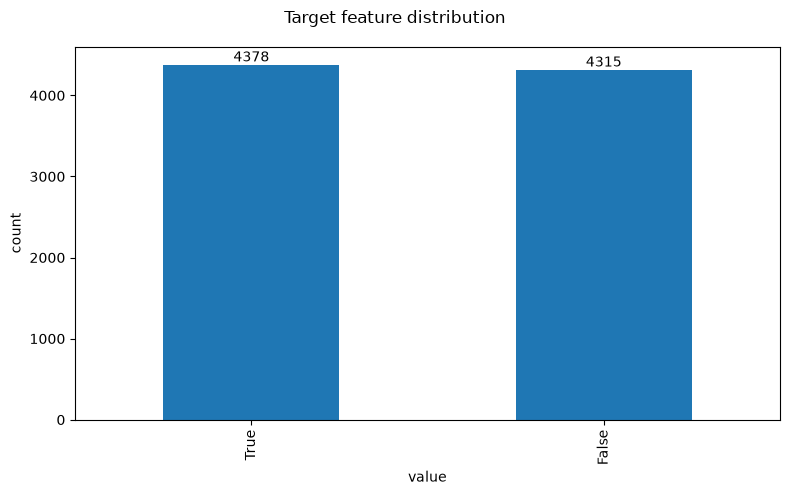

In [13]:
ax = df[TARGET].value_counts().plot(kind='bar', figsize=(8, 5))
for i in ax.containers:
    ax.bar_label(i)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
            
plt.suptitle("Target feature distribution")

plt.tight_layout()
plt.show()

We can see that the target feature is distributed equally. That means we can use accuracy as a metric.

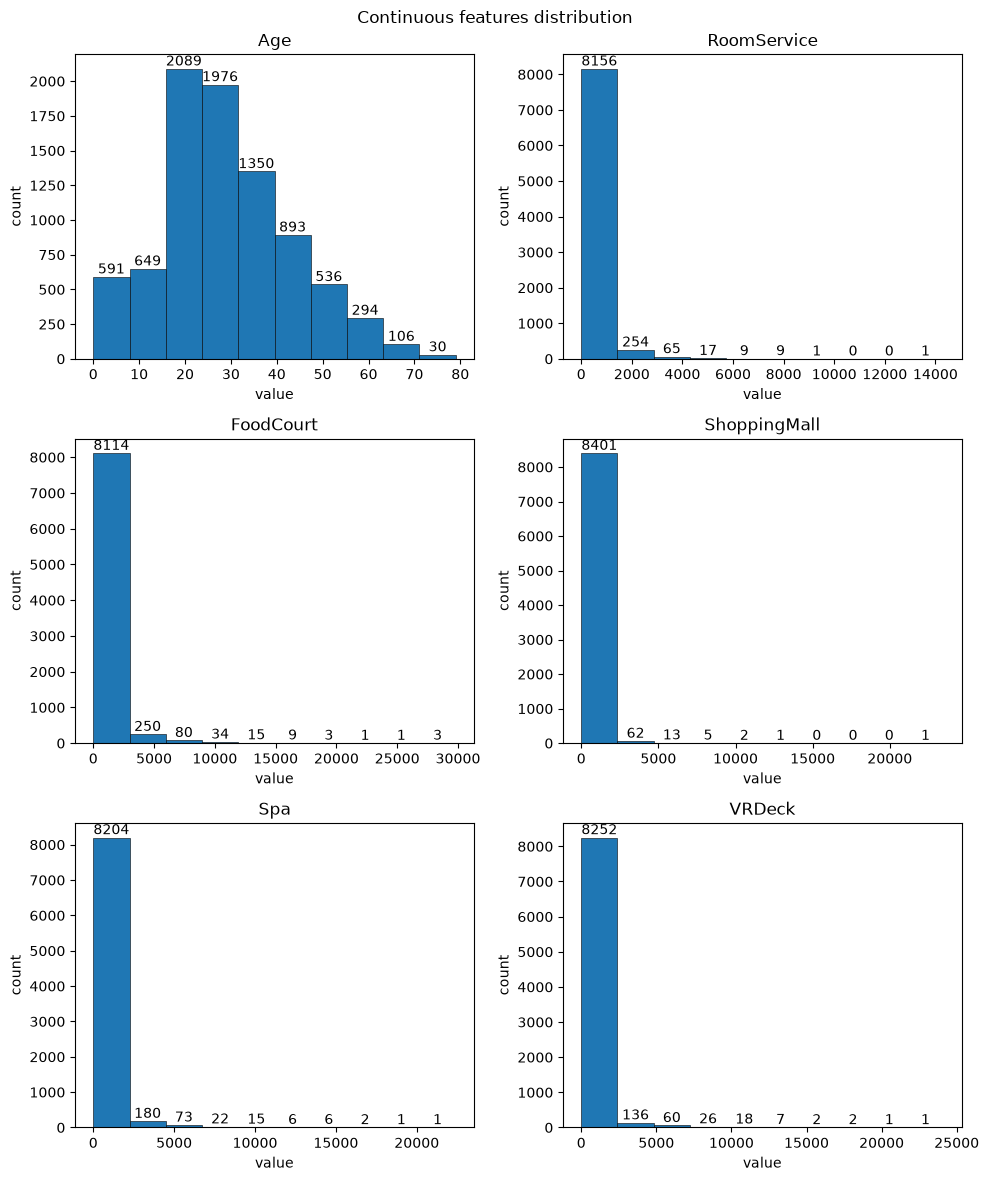

In [14]:
# Continuous features

ax = df.loc[:, cont_features].hist(figsize=(10, 12), grid=False, edgecolor='black', linewidth=.4)
for row in ax:
    for col in row:
        for i in col.containers:
            col.bar_label(i)
            col.set_xlabel("value")
            col.set_ylabel("count")
        
plt.suptitle("Continuous features distribution")

plt.tight_layout()
plt.show()

It looks like most of the passengers didn't use luxury services - all luxury amenities plots are heavily left-skewed. Let's create binary features for this services: if passanger used the service or not.

In [15]:
services_features = cont_features[1:]

In [16]:
for feature in services_features:
    df[f'used_{feature}'] = df.loc[:, feature].apply(lambda x: 1 if x > 0 else 0)

In [17]:
# Correlation matrix

df.loc[:, cont_features + ['CryoSleep', 'VIP', TARGET]].corr().style.background_gradient()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CryoSleep,VIP,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.074273,0.092819,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.252396,0.058785,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,-0.211510,0.129799,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,-0.212514,0.018295,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.203991,0.061059,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.198857,0.125974,-0.207075
CryoSleep,-0.074273,-0.252396,-0.211510,-0.212514,-0.203991,-0.198857,1.000000,-0.081402,0.468645
VIP,0.092819,0.058785,0.129799,0.018295,0.061059,0.125974,-0.081402,1.000000,-0.037650
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,0.468645,-0.037650,1.000000


We can see that input features are not correlated with oneself. So we won't drop any of the features.

## Preprocessing

In [18]:
# Imputing Missing Values 

imputer_cols = ["Age", "FoodCourt", "ShoppingMall", "Spa", "VRDeck" ,"RoomService"]
imputer = SimpleImputer(strategy='median')
imputer.fit(df[imputer_cols])
df[imputer_cols] = imputer.transform(df[imputer_cols])

In [19]:
df["HomePlanet"].fillna('Gallifrey', inplace=True)
df["Destination"].fillna('Skaro', inplace=True)

PassengerId
0001_01      TRAPPIST-1e
0002_01      TRAPPIST-1e
0003_01      TRAPPIST-1e
0003_02      TRAPPIST-1e
0004_01      TRAPPIST-1e
               ...      
9276_01      55 Cancri e
9278_01    PSO J318.5-22
9279_01      TRAPPIST-1e
9280_01      55 Cancri e
9280_02      TRAPPIST-1e
Name: Destination, Length: 8693, dtype: str

In [20]:
df['CryoSleep_is_missing'] = df['CryoSleep'].isna().astype(int)
df['VIP_is_missing'] = df['VIP'].isna().astype(int)

In [21]:
display(df['CryoSleep'].value_counts())
display(df['VIP'].value_counts())

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

VIP
False    8291
True      199
Name: count, dtype: int64

In [22]:
# TODO: Does not work in the new pandas versions
# df["CryoSleep"].fillna(False, inplace=True)
# df["VIP"].fillna(False, inplace=True)

# Do either this
# df["CryoSleep"] = df["CryoSleep"].fillna(False)
# df["VIP"] = df["VIP"].fillna(df["VIP"].median())

# Or this
df.fillna({"CryoSleep": False, "VIP": False}, inplace=True)

df["CryoSleep"] = df["CryoSleep"].astype(int)
df["VIP"] = df["VIP"].astype(int)

In [23]:
dummies = pd.get_dummies(df.loc[:, ['HomePlanet', 'Destination']], dtype=int)

In [24]:
dummies

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
PassengerId,,,,,,
0001_01,0,1,0,0,0,1
0002_01,1,0,0,0,0,1
0003_01,0,1,0,0,0,1
0003_02,0,1,0,0,0,1
0004_01,1,0,0,0,0,1
...,...,...,...,...,...,...
9276_01,0,1,0,1,0,0
9278_01,1,0,0,0,1,0
9279_01,1,0,0,0,0,1


In [25]:
df = pd.concat([df, dummies], axis=1)
df.drop(columns=['HomePlanet', 'Destination'], inplace=True)

In [26]:
df[TARGET] = df[TARGET].astype(int)

In [27]:
# For now, dropping textual features

df.drop(["Name" ,"Cabin"] , axis=1 ,inplace = True)

In [28]:
# Train/test split

X = df.drop(TARGET , axis = 1)
y = df[TARGET]

X_train , X_test , y_train , y_test = train_test_split(X, y, random_state = 42, test_size =0.33, stratify=y)
# use stratify=y to ensure that the distribution of the target variable will be preserved in train/test datasets

In [29]:
# For further computation purpuses, let's transpose input data

x_train = X_train.T
x_test = X_test.T
y_train = np.expand_dims(y_train.T, 0)
y_test = np.expand_dims(y_test.T, 0)

print('X train size', x_train.shape)
print('X test size', x_test.shape)
print('y train size', y_train.shape)
print('y test size', y_test.shape)

X train size (21, 5824)
X test size (21, 2869)
y train size (1, 5824)
y test size (1, 2869)


## Initializing parameters

In [30]:
# A function to initialize parameters

def initialize_weights_and_bias(dimension):
    # dimension - number of input features
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w, b

## Forward Propagation

In [31]:
def sigmoid(z):
    y_head = 1/(1+np.exp(-z))
    return y_head

In [32]:
def forward_propagation(w,b,x_train,y_train):
    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z) # probabilistic 0-1
    loss = -1*y_train*np.log(y_head)-(1-y_train)*np.log(1-y_head)
    cost = (np.sum(loss))/x_train.shape[1]      # x_train.shape[1]  is for scaling
    return cost 

## Gradient Descent

In [33]:
# Compute BCE loss and cost
def compute_cost(y: np.ndarray, y_hat: np.ndarray, eps: float = 1e-5) -> np.float64:
    loss = -1 * y * np.log(y_hat + eps)-(1 - y) * np.log(1 - y_hat + eps)
    cost = (np.sum(loss)) / len(y_hat)     
    return cost

In [34]:
compute_cost(np.array([[1, 1, 0]]), np.array([[0.8, 0.1, 0.2]]))

np.float64(2.74874720077838)

In [35]:
# Forward the network
def forward(w: np.ndarray, b: np.ndarray, x: np.ndarray):
    z = w.T @ x + b # synonym of np.dot(w.T, x) + b
    y = sigmoid(z)
    return y

In [ ]:
# Backward pass
def backward(y: np.ndarray, y_hat: np.ndarray) -> Tuple[np.float64, Dict]:
    # compute the cost function
    cost = compute_cost(y_train, y_hat)

    # Gradients computation
    derivative_weight = x_train @ ((y_hat - y).T)

    # Average the weight gradients
    total_number = x_train.shape[1]
    derivative_weight /= total_number

    # Bias gradients
    derivative_bias = np.sum(y_hat - y)
    # Average the bias gradients
    derivative_bias /= total_number

    gradients = {"derivative_weight": derivative_weight,"derivative_bias": derivative_bias}
    return cost, gradients

In [ ]:
# Run our neural network with forward and backward propagation
def forward_backward_propagation(w,b,x_train,y_train):
    # forward propagation
    y_hat = forward(w, b, x_train)
    cost, gradients = backward(y_train, y_hat)
    return cost, gradients

In [38]:
# Inference: turn probabilities into 0/1 labels
def predict(w: np.ndarray, b: np.ndarray, x_test: np.ndarray) -> np.ndarray:
    # reuse the same forward pass as in training, so train and inference match
    y_hat = np.asarray(forward(w, b, x_test))

    # if the probability is bigger than 0.5, the prediction is 1, otherwise 0
    return (y_hat > 0.5).astype(int)

In [39]:
# Updating(learning) 
# Compute BCE loss and cost
def compute_cost(y: np.ndarray, y_hat: np.ndarray, eps=1e-5) -> np.float32:
    loss = -1 * y * np.log(y_hat + eps) - (1 - y) * np.log(1 - y_hat + eps)
    cost = (np.sum(loss)) / len(y_hat)     
    return cost 

def update(w, b, x_train, y_train, x_test, y_test, learning_rate,number_of_iterarion):
    cost_list = []
    test_cost_list = []
    index = []    

    # updating(learning) parameters is number_of_iterarion times
    for i in range(number_of_iterarion):

        # make forward and backward propagation and find cost and gradients
        cost, gradients = forward_backward_propagation(w,b,x_train,y_train)
        cost_list.append(cost)

        # estimate test set loss
        y_hat_test = forward(w, b, x_test)
        test_cost = compute_cost(y_test, y_hat_test)
        test_cost_list.append(test_cost)

        # lets update
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]

        # Verbose the changes
        print(f"Iteration {i}: w = {" ".join(map(lambda x: f"{x:0.2f}", w.squeeze()))}\n\tb = {b}")
        index.append(i)

    # we update(learn) parameters weights and bias
    parameters = {"weight": w,"bias": b}
    plt.plot(index,cost_list)
    plt.plot(index,test_cost_list)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("Cost")
    plt.legend(["Train", "Test"])
    plt.show()
    
    return parameters, gradients, cost_list

Lets put them all together

In [40]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate ,  num_iterations):
    
    # initialize
    
    dimension =  x_train.shape[0]  # that is 4096
    w,b = initialize_weights_and_bias(dimension)
    
    # do not change learning rate
    parameters, gradients, cost_list = update(w, b, x_train, y_train, x_test, y_test, learning_rate,num_iterations)
    
    y_prediction_test = predict(parameters["weight"],parameters["bias"],x_test)
    y_prediction_train = predict(parameters["weight"],parameters["bias"],x_train)

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))

Iteration 0: w = 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -3.111573021958538e-06
Iteration 1: w = 0.01 0.01 0.01 0.01 0.01 0.01 0.00 0.00 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -6.214390348802776e-06
Iteration 2: w = 0.01 0.01 0.01 0.00 0.00 0.01 0.00 0.00 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -9.292401664544492e-06
Iteration 3: w = 0.01 0.01 0.01 0.00 0.00 0.01 -0.00 -0.00 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -1.225957854964375e-05
Iteration 4: w = 0.01 0.01 0.01 0.00 0.00 0.01 -0.00 -0.00 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -1.4469005908568058e-05
Iteration 5: w = 0.01 0.01 0.01 -0.00 0.00 0.01 -0.00 -0.00 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
	b = -1.5382080791690527e-05
Iteration 6: w = 0.01 0.01 0.01 -0.00 0.00 0.00 -0.00 -0.00 0.01 0.01 0.01 0.01 0.01 0.01 0

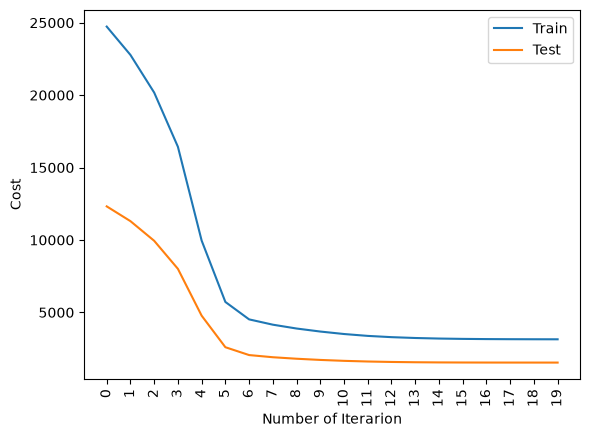

train accuracy: 78.0048076923077 %
test accuracy: 79.40048797490414 %


In [42]:
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 0.00001, num_iterations = 20) 

## А що, якби ми не використовували bias?

Наша функція `forward()` обчислює `z = w.T @ x + b`. Bias займає рівно один параметр із 22 — чи щось змінилося б, якби ми його прибрали й залишили лише `z = w.T @ x`?

Геометрично bias зміщує межу прийняття рішення: межа — це множина точок, для яких `z = 0`, а без члена bias вона змушена проходити через початок координат простору ознак.

Еквівалентно, `b` — це те, що дозволяє моделі виразити ***апріорну ймовірність*** — наскільки ймовірно, що пасажир буде перевезений, ще до того, як ми врахуємо будь-які ознаки.

Навчімо ту саму логістичну регресію двічі — один раз із `z = w.T @ x + b`, а другий — із `z = w.T @ x` — і порівняємо історії значень вартості.

Наведені вище функції залишаємо без змін, усе, що нижче, визначаємо заново.


In [43]:
# The forward pass without the bias term - the only difference from forward() is the missing "+ b"
def forward_no_bias(w: np.ndarray, b: np.ndarray, x: np.ndarray) -> np.ndarray:
    z = w.T @ x
    y = sigmoid(z)
    return y


# The same gradients as in backward(), but x and y are passed explicitly:
# backward() reads x_train / y_train from the global scope, and below we will feed the model other data
def compute_gradients(x: np.ndarray, y: np.ndarray, y_hat: np.ndarray) -> Dict:
    total_number = x.shape[1]

    derivative_weight = (x @ ((y_hat - y).T)) / total_number
    derivative_bias = np.sum(y_hat - y) / total_number

    return {"derivative_weight": derivative_weight, "derivative_bias": derivative_bias}


# Share of the correct predictions, the same formula as in logistic_regression()
def accuracy(y: np.ndarray, y_prediction: np.ndarray) -> np.float64:
    return 100 - np.mean(np.abs(y_prediction - y)) * 100

In [44]:
# The same update loop as above, but it only collects the cost history
# use_bias=False drops the "+ b" term from the forward pass, the rest stays the same
def train_and_track(x_train, y_train, x_test, y_test, learning_rate, number_of_iterarion, use_bias=True):

    w, b = initialize_weights_and_bias(x_train.shape[0])
    forward_pass = forward if use_bias else forward_no_bias

    cost_list = []
    test_cost_list = []

    for i in range(number_of_iterarion):

        # forward propagation on both sets
        y_hat = np.asarray(forward_pass(w, b, x_train))
        y_hat_test = np.asarray(forward_pass(w, b, x_test))

        # compute_cost() divides by len(y_hat), and that is 1 for a (1, n) array,
        # so we average over the samples here to get the mean loss per passenger
        cost_list.append(compute_cost(y_train, y_hat) / y_train.shape[1])
        test_cost_list.append(compute_cost(y_test, y_hat_test) / y_test.shape[1])

        # lets update
        gradients = compute_gradients(x_train, y_train, y_hat)
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]

    parameters = {"weight": w, "bias": b}
    return parameters, cost_list, test_cost_list

In [45]:
# x_train / x_test are DataFrames, and below we will need to scale and slice them
x_train_values = np.asarray(x_train, dtype=float)
x_test_values = np.asarray(x_test, dtype=float)

# the same learning rate as in the run above
learning_rate = 0.00001
num_iterations = 100

parameters_bias, cost_bias, test_cost_bias = train_and_track(
    x_train_values, y_train, x_test_values, y_test, learning_rate, num_iterations, use_bias=True)

parameters_no_bias, cost_no_bias, test_cost_no_bias = train_and_track(
    x_train_values, y_train, x_test_values, y_test, learning_rate, num_iterations, use_bias=False)

print("Train cost: {:.6f} with bias, {:.6f} without bias".format(cost_bias[-1], cost_no_bias[-1]))
print("Test cost:  {:.6f} with bias, {:.6f} without bias".format(test_cost_bias[-1], test_cost_no_bias[-1]))
print("Largest difference between the two train histories: {:.2e}".format(
    max(np.abs(np.array(cost_bias) - np.array(cost_no_bias)))))
print("Learned bias: {:.3e}".format(float(parameters_bias["bias"])))

Train cost: 0.536765 with bias, 0.536768 without bias
Test cost:  0.531805 with bias, 0.531807 without bias
Largest difference between the two train histories: 2.29e-06
Learned bias: 3.989e-05


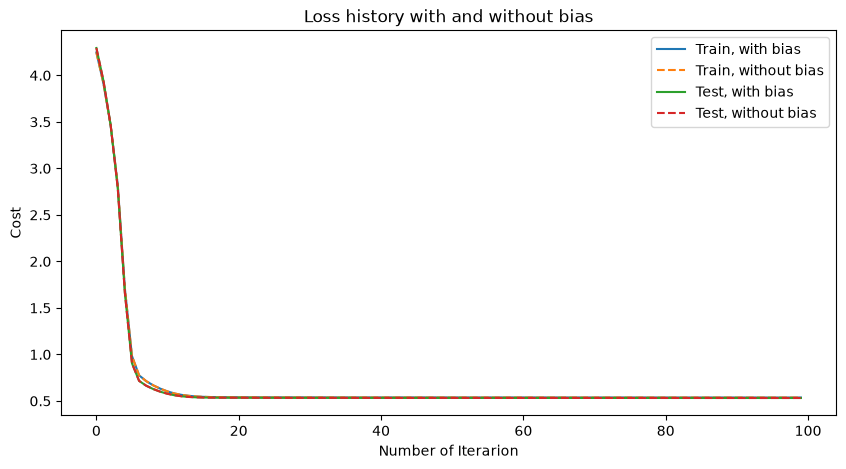

In [46]:
index = list(range(num_iterations))

plt.figure(figsize=(10, 5))
plt.plot(index, cost_bias)
plt.plot(index, cost_no_bias, linestyle='--')
plt.plot(index, test_cost_bias)
plt.plot(index, test_cost_no_bias, linestyle='--')
plt.xlabel("Number of Iterarion")
plt.ylabel("Cost")
plt.title("Loss history with and without bias")
plt.legend(["Train, with bias", "Train, without bias", "Test, with bias", "Test, without bias"])
plt.show()

In [47]:
# And the accuracy - predict() uses forward(), so it scores the model with the bias
y_prediction_bias = predict(parameters_bias["weight"], parameters_bias["bias"], x_test_values)
y_prediction_no_bias = (np.asarray(
    forward_no_bias(parameters_no_bias["weight"], parameters_no_bias["bias"], x_test_values)) > 0.5).astype(int)

print("test accuracy with bias:    {} %".format(accuracy(y_test, y_prediction_bias)))
print("test accuracy without bias: {} %".format(accuracy(y_test, y_prediction_no_bias)))

test accuracy with bias:    79.40048797490414 %
test accuracy without bias: 79.40048797490414 %


Чотири криві накладаються одна на одну, а точність абсолютно однакова — вивчений bias має порядок величини

`1e-05`, тому модель із bias фактично ніколи не відійшла від рішення без bias. Для цього є дві причини,

і обидві стосуються *\*саме цього\** налаштування, а не члена bias загалом:

* Ознаки не масштабовані (`Spa` сягає 6715, а `VIP` має значення 0 або 1), тому швидкість навчання має бути дуже малою через

  це. Градієнт bias — це одне число, `mean(y_hat - y)`, і при `learning_rate = 1e-05` він змінює `b`

  лише на мільйонну частку за одну ітерацію, тоді як ваги великих ознак значно швидше змінюють прогноз.

* Цільова змінна збалансована (приблизно 50 / 50), тому вільний член, до якого модель у результаті збіглася б,

  у будь-якому разі був би близьким до нуля.

Тож усуньмо обидві перешкоди: масштабуймо ознаки (тоді можна використовувати нормальну швидкість навчання)

і зробімо навчальний набір незбалансованим, залишивши лише 10% перевезених пасажирів. Тепер модель *\*має\**

змістити межу подалі від початку координат — і саме для цього потрібен bias.

In [48]:
# Standardize the features using the train set statistics, so that a normal learning rate can be used
mean = x_train_values.mean(axis=1, keepdims=True)
std = x_train_values.std(axis=1, keepdims=True)
std[std == 0] = 1.0

x_train_scaled = (x_train_values - mean) / std
x_test_scaled = (x_test_values - mean) / std

# Make the train set imbalanced: keep all the non-transported passengers, but only 10% of the transported ones
rng = np.random.default_rng(42)
positive = np.flatnonzero(y_train[0] == 1)
negative = np.flatnonzero(y_train[0] == 0)
keep = np.concatenate([negative, rng.choice(positive, size=len(positive) // 10, replace=False)])

x_train_skewed = x_train_scaled[:, keep]
y_train_skewed = y_train[:, keep]

share = y_train_skewed.mean()
print("Share of the transported passengers in the skewed train set: {:.4f}".format(share))
print("Log-odds of that share: {:.4f}".format(np.log(share / (1 - share))))

Share of the transported passengers in the skewed train set: 0.0920
Log-odds of that share: -2.2892


In [49]:
learning_rate = 0.5
num_iterations = 300

# scaled features, the original balanced train set
parameters_scaled_bias, cost_scaled_bias, _ = train_and_track(
    x_train_scaled, y_train, x_test_scaled, y_test, learning_rate, num_iterations, use_bias=True)
parameters_scaled_no_bias, cost_scaled_no_bias, _ = train_and_track(
    x_train_scaled, y_train, x_test_scaled, y_test, learning_rate, num_iterations, use_bias=False)

# scaled features, the imbalanced train set
parameters_skewed_bias, cost_skewed_bias, _ = train_and_track(
    x_train_skewed, y_train_skewed, x_test_scaled, y_test, learning_rate, num_iterations, use_bias=True)
parameters_skewed_no_bias, cost_skewed_no_bias, _ = train_and_track(
    x_train_skewed, y_train_skewed, x_test_scaled, y_test, learning_rate, num_iterations, use_bias=False)

print("Balanced train set: {:.4f} with bias, {:.4f} without bias (learned b = {:.4f})".format(
    cost_scaled_bias[-1], cost_scaled_no_bias[-1], float(parameters_scaled_bias["bias"])))
print("Skewed train set:   {:.4f} with bias, {:.4f} without bias (learned b = {:.4f})".format(
    cost_skewed_bias[-1], cost_skewed_no_bias[-1], float(parameters_skewed_bias["bias"])))

Balanced train set: 0.4472 with bias, 0.4502 without bias (learned b = -0.2070)
Skewed train set:   0.2100 with bias, 0.4371 without bias (learned b = -2.3274)


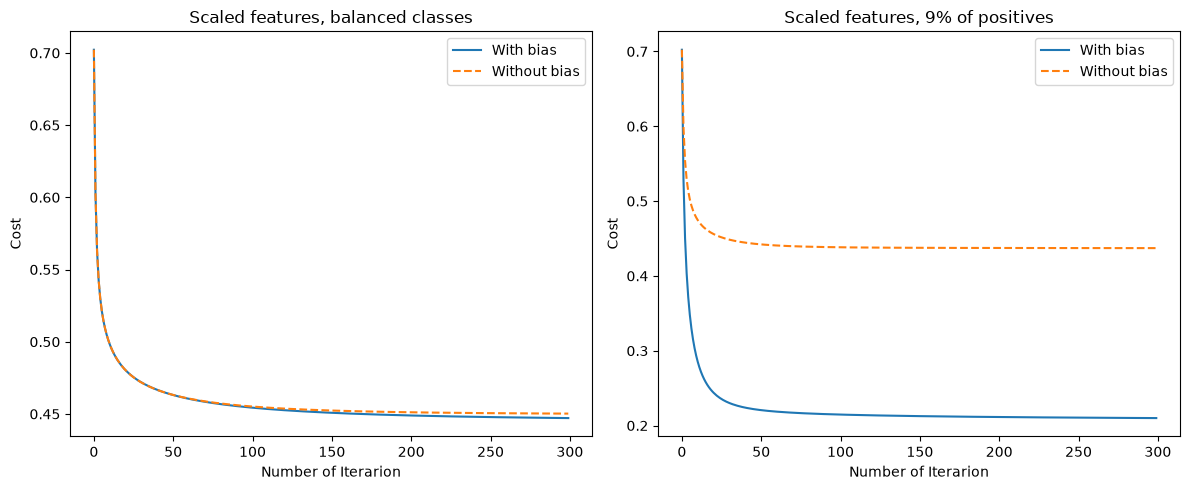

In [50]:
index = list(range(num_iterations))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(index, cost_scaled_bias)
plt.plot(index, cost_scaled_no_bias, linestyle='--')
plt.xlabel("Number of Iterarion")
plt.ylabel("Cost")
plt.title("Scaled features, balanced classes")
plt.legend(["With bias", "Without bias"])

plt.subplot(1, 2, 2)
plt.plot(index, cost_skewed_bias)
plt.plot(index, cost_skewed_no_bias, linestyle='--')
plt.xlabel("Number of Iterarion")
plt.ylabel("Cost")
plt.title("Scaled features, 9% of positives")
plt.legend(["With bias", "Without bias"])

plt.tight_layout()
plt.show()

### Відповідь

- Для **збалансованої** цільової змінної відмова від bias майже нічого не коштує: як для необроблених ознак, так і для

  масштабованих ознак дві історії навчання практично ідентичні (0.4472 проти 0.4502 після 300 ітерацій).

- Для **незбалансованого** навчального набору різниця значна — модель без bias застрягає приблизно на 0.44, тоді як модель із

  bias знижує значення до ~0.21. Без `b` кожне передбачення має вигляд `sigmoid(w.T @ x)`, що дорівнює 0.5 при `x = 0`, тому модель

  змушена витрачати свої ваги на зміщення всієї хмари точок в один бік замість того, щоб використовувати їх для розділення

  класів.

- Bias, який вивчає модель, — не довільне число: він збігається до логарифма відношення шансів апріорної ймовірності класу,

  `log(0.092 / 0.908) = -2.29`, що й показує наведений вище вивід.

**Евристичне правило:** bias коштує лише одного параметра й усуває довільне обмеження моделі, тому його варто залишати. Без нього

можна обійтися лише тоді, коли ознаки центровані **i** класи збалансовані, або коли матриця ознак уже містить

постійну колонку з одиниць — тоді вага цієї колонки виконує роль bias. Зверніть увагу, що

`nn.Linear` у PyTorch має `bias=True` за замовчуванням саме з цієї причини.